In [1]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

file_path = "Reddit_Combined_Data.xlsx"
df = pd.read_excel(file_path, sheet_name="Train")


In [3]:
def combine_text(row):
    title = str(row.get("title", "") or "")
    body = str(row.get("selftext", "") or "")
    # Add a separator so title and body are not glued together
    return title.strip() + " [SEP] " + body.strip()

df["text"] = df.apply(combine_text, axis=1)

print("Example combined text:")
print(df[["title", "selftext", "text"]].head(3))


Example combined text:
                                               title  \
0                        Do people get over anxiety?   
1  does anyone else have this big fear of suddenl...   
2         3 hour long panic attack after trying weed   

                                            selftext  \
0  Tried to watch this documentary “anxious Ameri...   
1  i’m currently laying in bed wide awake, feelin...   
2  Second time trying weed. First time felt close...   

                                                text  
0  Do people get over anxiety? [SEP] Tried to wat...  
1  does anyone else have this big fear of suddenl...  
2  3 hour long panic attack after trying weed [SE...  


In [4]:
import numpy as np
import pandas as pd

# Convert problematic strings to proper NaN
def clean_str(x):
    if x is None:
        return np.nan
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null", "", "na"]:
        return np.nan
    return x

# Clean all relevant raw columns
raw_cols = ["Perceived severity", "Self-efficacy", "Cue to Action"]

for col in raw_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_str)

print("Raw columns cleaned.")


Raw columns cleaned.


In [5]:
def map_severity(raw):
    if pd.isna(raw):
        return "Not mentioned"

    s = raw.lower()

    # anxiety / panic
    if "anxiety" in s or "panic" in s:
        return "Anxiety/Panic"

    # depression variants
    if "depress" in s:
        return "Depression"

    # PTSD / severe disorders / trauma
    if "ptsd" in s or "trauma" in s or "severe" in s:
        return "Severe/PTSD"

    # loneliness
    if "lonely" in s or "isolation" in s or "alone" in s:
        return "Loneliness/Isolation"

    # substance
    if "addict" in s or "alcohol" in s or "drug" in s or "substance" in s:
        return "Substance-related"

    # fallback: treat everything unknown as "Other"
    return "Other"

df["severity_merged"] = df["Perceived severity"].apply(map_severity)

print("Severity merged distribution:")
print(df["severity_merged"].value_counts())


Severity merged distribution:
severity_merged
Depression           343
Anxiety/Panic        277
Other                138
Substance-related     23
Severe/PTSD           19
Name: count, dtype: int64


In [6]:
def map_self_efficacy(raw):
    if pd.isna(raw):
        return np.nan

    s = raw.strip()

    # High self-efficacy group
    if s in ["Empowered Mindset", "Overcome Mindset"]:
        return "High self-efficacy"

    # Low self-efficacy group
    if s in ["Troubled Mindset", "Denial Mindset"]:
        return "Low self-efficacy"

    return np.nan  # treat anything else as unknown

df["Self_eff_merged"] = df["Self-efficacy"].apply(map_self_efficacy)

print("Self-efficacy merged distribution:")
print(df["Self_eff_merged"].value_counts(dropna=False))


Self-efficacy merged distribution:
Self_eff_merged
Low self-efficacy     519
High self-efficacy    281
Name: count, dtype: int64


In [7]:
def map_cue_action(raw):
    if pd.isna(raw):
        return "No clear action"

    s = raw.lower()

    # help-seeking or treatment
    if "help" in s or "therapy" in s or "treatment" in s or "doctor" in s:
        return "Help-seeking/treatment"

    # information seeking
    if "advice" in s or "info" in s or "information" in s or "suggest" in s:
        return "Information seeking"

    # sharing / community support
    if "share" in s or "experience" in s or "story" in s or "discussion" in s:
        return "Sharing/community"

    return "No clear action"

df["Cue_group"] = df["Cue to Action"].apply(map_cue_action)

print("Cue group distribution:")
print(df["Cue_group"].value_counts())


Cue group distribution:
Cue_group
No clear action           608
Information seeking       105
Help-seeking/treatment     87
Name: count, dtype: int64


In [8]:
TASK_CONFIGS = {
    "sentiment": {
        "label_col": "Sentiment",
        "label_map": {
            "Negative": 0,
            "Neutral": 1,
            "Positive": 2
        }
    },
    "severity_merged": {
        "label_col": "severity_merged",   # from your new mapping cell
        "label_map": None                 # auto-map labels
    },
    "self_efficacy_binary": {
        "label_col": "Self_eff_merged",   # from your new mapping cell
        "label_map": None                 # auto-map ("High self-efficacy", "Low self-efficacy")
    },
    "cue_to_action": {
        "label_col": "Cue_group",         # from your new mapping cell
        "label_map": None                 # auto-map
    }
}


In [9]:
print(df.columns.tolist())


['score', 'selftext', 'subreddit', 'title', 'Root cause', 'Gender', 'Sentiment', 'Perceived severity', 'Perceived benefits', 'Perceived barriers', 'Cue to Action', 'Self-efficacy', 'text', 'severity_merged', 'Self_eff_merged', 'Cue_group']


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np


In [11]:
def prepare_task_data(
    df,
    text_col,
    label_col,
    label_map=None,
    test_size=0.2,
    random_state=42,
    min_samples_per_class=1
):
    """
    - Drops rows where text or label is missing
    - Optionally filters out rare classes
    - Maps string labels to integers (auto if label_map is None)
    - Splits into train and test with stratification
    """

    # 1. Keep only rows where text and label are present
    if label_col not in df.columns:
        raise KeyError(f"Column '{label_col}' not found in dataframe.")

    data = df.dropna(subset=[text_col, label_col]).copy()

    # 2. Optionally drop very rare classes (useful for severity/cue)
    if min_samples_per_class > 1:
        counts = data[label_col].value_counts()
        valid_classes = counts[counts >= min_samples_per_class].index
        data = data[data[label_col].isin(valid_classes)]

    # 3. If no custom label_map → create automatically from unique labels
    if label_map is None:
        unique_labels = sorted(data[label_col].unique())
        label_map = {name: idx for idx, name in enumerate(unique_labels)}
        print(f"\nAuto-generated label_map for '{label_col}':")
        for k, v in label_map.items():
            print(f"  {v}: {k}")

    # 4. Map labels to integers
    data["label_id"] = data[label_col].map(label_map)
    data = data.dropna(subset=["label_id"])
    data["label_id"] = data["label_id"].astype(int)

    print(f"\nPreparing task for label_col = {label_col}")
    print("Label distribution (string):")
    print(data[label_col].value_counts())

    # 5. Check number of classes
    n_classes = data["label_id"].nunique()
    if n_classes < 2:
        print(f"\n⚠️ WARNING: Only {n_classes} class found for '{label_col}'. "
              "Need at least 2 classes to train a classifier. Skipping this task.")
        return None, None, None, None, label_map

    # 6. Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        data[text_col],
        data["label_id"],
        test_size=test_size,
        stratify=data["label_id"],
        random_state=random_state
    )

    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    return X_train, X_test, y_train, y_test, label_map


In [12]:
def train_tfidf_logreg_for_task(
    X_train,
    X_test,
    y_train,
    y_test,
    label_map,
    ngram_range=(1, 2),
    max_features=10000
):
    """
    - TF-IDF (unigrams + bigrams)
    - Logistic Regression with class_weight='balanced'
    - Prints metrics and returns model + vectorizer + scores
    """

    print("\nVectorizing text with TF-IDF...")
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        stop_words="english"
    )
    X_train_tf = vectorizer.fit_transform(X_train)
    X_test_tf = vectorizer.transform(X_test)

    print("Training Logistic Regression...")
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        n_jobs=-1
    )
    clf.fit(X_train_tf, y_train)

    print("Evaluating on test set...")
    y_pred = clf.predict(X_test_tf)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"\nAccuracy: {acc:.3f}")
    print(f"Macro F1: {macro_f1:.3f}")
    print(f"Weighted F1: {weighted_f1:.3f}")

    # Build labels & names only for classes that actually appear
    unique_ids = sorted(np.unique(np.concatenate([y_test, y_pred])))
    id2name = {v: k for k, v in label_map.items()}

    labels = []
    target_names = []
    for lid in unique_ids:
        if lid in id2name:
            labels.append(lid)
            target_names.append(id2name[lid])

    print("\nClassification report (only for labels present in test data):")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            zero_division=0
        )
    )

    return {
        "vectorizer": vectorizer,
        "model": clf,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


In [13]:
def run_task(task_name, df, text_col="text", test_size=0.2):
    """
    Runs the full pipeline for a given task:
    - Look up config
    - Prepare data
    - Train TF-IDF + Logistic Regression
    - Return metrics dict
    """
    assert task_name in TASK_CONFIGS, f"Unknown task: {task_name}"
    cfg = TASK_CONFIGS[task_name]

    label_col = cfg["label_col"]
    cfg_label_map = cfg["label_map"]  # may be dict or None

    # Decide how aggressively to filter rare classes
    if task_name in ["severity_merged", "cue_to_action"]:
        min_samples = 2   # ignore labels that appear only once
    else:
        min_samples = 1

    # 1. Prepare data (may auto-generate a label_map)
    X_train, X_test, y_train, y_test, used_label_map = prepare_task_data(
        df,
        text_col=text_col,
        label_col=label_col,
        label_map=cfg_label_map,
        test_size=test_size,
        random_state=42,
        min_samples_per_class=min_samples
    )

    # If we couldn't prepare data (e.g. <2 classes), skip training
    if X_train is None:
        print(f"⏭️ Skipping task '{task_name}' because it has fewer than 2 classes.")
        return {
            "task": task_name,
            "label_col": label_col,
            "accuracy": None,
            "macro_f1": None,
            "weighted_f1": None,
            "model": None,
            "vectorizer": None
        }

    # 2. Train + evaluate model
    results = train_tfidf_logreg_for_task(
        X_train, X_test, y_train, y_test,
        label_map=used_label_map
    )

    # 3. Attach metadata
    results["task"] = task_name
    results["label_col"] = label_col
    return results


In [14]:
all_results = []

for task_name in ["sentiment", "severity_merged", "self_efficacy_binary", "cue_to_action"]:
    print("\n" + "="*70)
    print(f"Running task: {task_name}")
    print("="*70)
    res = run_task(task_name, df)
    all_results.append(res)



Running task: sentiment

Preparing task for label_col = Sentiment
Label distribution (string):
Sentiment
Negative    492
Neutral     244
Positive     64
Name: count, dtype: int64
Train size: 640, Test size: 160

Vectorizing text with TF-IDF...
Training Logistic Regression...
Evaluating on test set...

Accuracy: 0.675
Macro F1: 0.470
Weighted F1: 0.645

Classification report (only for labels present in test data):
              precision    recall  f1-score   support

    Negative       0.73      0.87      0.79        98
     Neutral       0.52      0.45      0.48        49
    Positive       0.50      0.08      0.13        13

    accuracy                           0.68       160
   macro avg       0.59      0.46      0.47       160
weighted avg       0.65      0.68      0.65       160


Running task: severity_merged

Auto-generated label_map for 'severity_merged':
  0: Anxiety/Panic
  1: Depression
  2: Other
  3: Severe/PTSD
  4: Substance-related

Preparing task for label_col = sev

In [15]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "Task": r["task"],
        "Label Column": r["label_col"],
        "Accuracy": r["accuracy"],
        "Macro F1": r["macro_f1"],
        "Weighted F1": r["weighted_f1"]
    }
    for r in all_results
])

results_df


,Task,Label Column,Accuracy,Macro F1,Weighted F1
0,sentiment,Sentiment,0.67500,0.470414,0.645476
1,severity_merged,severity_merged,0.61250,0.399903,0.600508
2,self_efficacy_binary,Self_eff_merged,0.76250,0.729345,0.757764
3,cue_to_action,Cue_group,0.75625,0.498624,0.750768


In [16]:
####### Distilbert #############

In [17]:
!pip install -q transformers datasets torch



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [18]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"  # just to keep TF/Keras out

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


In [19]:
def build_hf_dataset_for_task(
    df,
    text_col: str,
    label_col: str,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic: builds a HuggingFace DatasetDict({train, test})
    for a given text column + label column.
    Returns: datasets, label2id, id2label
    """
    # 1. Drop rows with missing text or label
    data = df.dropna(subset=[text_col, label_col]).copy()

    # 2. Build label2id and id2label from unique labels
    unique_labels = sorted(data[label_col].unique())
    label2id = {name: idx for idx, name in enumerate(unique_labels)}
    id2label = {idx: name for name, idx in label2id.items()}

    print(f"\nBuilding dataset for label column = '{label_col}'")
    print("Labels and IDs:")
    for name, idx in label2id.items():
        print(f"  {idx}: {name}")

    # 3. Map labels to integers
    data["label"] = data[label_col].map(label2id).astype(int)

    # 4. Stratified train/test split
    train_df, test_df = train_test_split(
        data[[text_col, "label"]],
        test_size=test_size,
        stratify=data["label"],
        random_state=random_state
    )

    # 5. Build HF datasets
    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

    return DatasetDict({"train": train_ds, "test": test_ds}), label2id, id2label


In [20]:
def tokenize_and_build_dataloaders(
    datasets: DatasetDict,
    tokenizer,
    max_length: int = 256,
    batch_size: int = 8
):
    """
    Tokenizes the HF datasets and returns train/test DataLoaders.
    """
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    tokenized = datasets.map(tokenize_batch, batched=True)

    # Remove all columns except input_ids, attention_mask, label
    for split in ["train", "test"]:
        cols = tokenized[split].column_names
        drop_cols = [c for c in cols if c not in ["input_ids", "attention_mask", "label"]]
        tokenized[split] = tokenized[split].remove_columns(drop_cols)

    tokenized.set_format(type="torch")

    train_loader = DataLoader(tokenized["train"], batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(tokenized["test"], batch_size=batch_size)

    return train_loader, test_loader


In [21]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return acc, macro_f1, weighted_f1


In [22]:
def train_transformer_for_task(
    df,
    text_col: str,
    label_col: str,
    model_name: str = "distilbert-base-uncased",
    num_epochs: int = 5,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    max_length: int = 256,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic end-to-end training for a single text classification task.
    Returns:
      - best_metrics dict
      - best_epoch
      - label2id, id2label
      - trained model (at best epoch)
    """
    # 1. Build dataset
    datasets, label2id, id2label = build_hf_dataset_for_task(
        df,
        text_col=text_col,
        label_col=label_col,
        test_size=test_size,
        random_state=random_state
    )

    # 2. Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 3. Dataloaders
    train_loader, test_loader = tokenize_and_build_dataloaders(
        datasets, tokenizer, max_length=max_length, batch_size=batch_size
    )

    # 4. Model + optimizer
    num_labels = len(label2id)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # 5. Training loop with "best epoch" tracking (by macro F1)
    best_macro_f1 = -1.0
    best_metrics = None
    best_state_dict = None
    best_epoch = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}  |  Task: {label_col}")
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Train loss: {train_loss:.4f}")

        acc, macro_f1, weighted_f1 = evaluate(model, test_loader, device)
        print(f"Eval accuracy: {acc:.4f}")
        print(f"Eval macro F1: {macro_f1:.4f}")
        print(f"Eval weighted F1: {weighted_f1:.4f}")

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1
            best_metrics = {
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            }
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print("🔥 New best model found! Saving this checkpoint.")

    print("\n=== Best epoch summary ===")
    print(f"Task: {label_col}")
    print(f"Best epoch: {best_epoch}")
    print(f"Best accuracy: {best_metrics['accuracy']:.4f}")
    print(f"Best macro F1: {best_metrics['macro_f1']:.4f}")
    print(f"Best weighted F1: {best_metrics['weighted_f1']:.4f}")

    # Load best weights back into the model
    model.load_state_dict(best_state_dict)
    model.to(device)

    return best_metrics, best_epoch, label2id, id2label, model


In [23]:
results_transformer = {}

# 1. Self-efficacy binary
metrics_se, epoch_se, l2i_se, i2l_se, model_se = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Self_eff_merged",
    model_name="distilbert-base-uncased",
    num_epochs=5,
    batch_size=8
)
results_transformer["self_efficacy_binary"] = metrics_se

# 2. Sentiment
metrics_sent, epoch_sent, l2i_sent, i2l_sent, model_sent = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Sentiment",
    model_name="distilbert-base-uncased",
    num_epochs=5,
    batch_size=8
)
results_transformer["sentiment"] = metrics_sent

# 3. Severity merged
metrics_sev, epoch_sev, l2i_sev, i2l_sev, model_sev = train_transformer_for_task(
    df,
    text_col="text",
    label_col="severity_merged",
    model_name="distilbert-base-uncased",
    num_epochs=5,
    batch_size=8
)
results_transformer["severity_merged"] = metrics_sev

# 4. Cue to action
metrics_cue, epoch_cue, l2i_cue, i2l_cue, model_cue = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Cue_group",
    model_name="distilbert-base-uncased",
    num_epochs=5,
    batch_size=8
)
results_transformer["cue_to_action"] = metrics_cue

results_transformer



Building dataset for label column = 'Self_eff_merged'
Labels and IDs:
  0: High self-efficacy
  1: Low self-efficacy


Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Using device: cuda


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda

Epoch 1/5  |  Task: Cue_group
Train loss: 0.7376
Eval accuracy: 0.7625
Eval macro F1: 0.2884
Eval weighted F1: 0.6598
🔥 New best model found! Saving this checkpoint.

Epoch 2/5  |  Task: Cue_group
Train loss: 0.5772
Eval accuracy: 0.7875
Eval macro F1: 0.3998
Eval weighted F1: 0.7232
🔥 New best model found! Saving this checkpoint.

Epoch 3/5  |  Task: Cue_group
Train loss: 0.4240
Eval accuracy: 0.7562
Eval macro F1: 0.4558
Eval weighted F1: 0.7412
🔥 New best model found! Saving this checkpoint.

Epoch 4/5  |  Task: Cue_group
Train loss: 0.3120
Eval accuracy: 0.7438
Eval macro F1: 0.5410
Eval weighted F1: 0.7536
🔥 New best model found! Saving this checkpoint.

Epoch 5/5  |  Task: Cue_group
Train loss: 0.2016
Eval accuracy: 0.7625
Eval macro F1: 0.5532
Eval weighted F1: 0.7668
🔥 New best model found! Saving this checkpoint.

=== Best epoch summary ===
Task: Cue_group
Best epoch: 5
Best accuracy: 0.7625
Best macro F1: 0.5532
Best weighted F1: 0.7668


{'self_efficacy_binary': {'accuracy': 0.75625,
  'macro_f1': 0.7262077135711464,
  'weighted_f1': 0.7534158220350139},
 'sentiment': {'accuracy': 0.74375,
  'macro_f1': 0.5444752857965293,
  'weighted_f1': 0.7272962543177892},
 'severity_merged': {'accuracy': 0.70625,
  'macro_f1': 0.4244322160182409,
  'weighted_f1': 0.6860272401658917},
 'cue_to_action': {'accuracy': 0.7625,
  'macro_f1': 0.5531778228532792,
  'weighted_f1': 0.7667972447599729}}

In [24]:
###### deberta-v3-base ########

In [25]:
!pip install -q sentencepiece



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [26]:
from transformers import DebertaV2Tokenizer

In [27]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DebertaV2Tokenizer,   # 👈 add this
)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


In [28]:
def build_hf_dataset_for_task(
    df,
    text_col: str,
    label_col: str,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic: builds a HuggingFace DatasetDict({train, test})
    for a given text column + label column.
    Returns: datasets, label2id, id2label
    """
    # 1. Drop rows with missing text or label
    data = df.dropna(subset=[text_col, label_col]).copy()

    # 2. Build label2id and id2label from unique labels
    unique_labels = sorted(data[label_col].unique())
    label2id = {name: idx for idx, name in enumerate(unique_labels)}
    id2label = {idx: name for name, idx in label2id.items()}

    print(f"\nBuilding dataset for label column = '{label_col}'")
    print("Labels and IDs:")
    for name, idx in label2id.items():
        print(f"  {idx}: {name}")

    # 3. Map labels to integers
    data["label"] = data[label_col].map(label2id).astype(int)

    # 4. Stratified train/test split
    train_df, test_df = train_test_split(
        data[[text_col, "label"]],
        test_size=test_size,
        stratify=data["label"],
        random_state=random_state
    )

    # 5. Build HF datasets
    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

    return DatasetDict({"train": train_ds, "test": test_ds}), label2id, id2label


In [29]:
def tokenize_and_build_dataloaders(
    datasets: DatasetDict,
    tokenizer,
    max_length: int = 256,
    batch_size: int = 8
):
    """
    Tokenizes the HF datasets and returns train/test DataLoaders.
    """
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    tokenized = datasets.map(tokenize_batch, batched=True)

    # Keep only input_ids, attention_mask, label
    for split in ["train", "test"]:
        cols = tokenized[split].column_names
        drop_cols = [c for c in cols if c not in ["input_ids", "attention_mask", "label"]]
        tokenized[split] = tokenized[split].remove_columns(drop_cols)

    tokenized.set_format(type="torch")

    train_loader = DataLoader(tokenized["train"], batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(tokenized["test"], batch_size=batch_size)

    return train_loader, test_loader


In [30]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return acc, macro_f1, weighted_f1


In [31]:
def train_transformer_for_task(
    df,
    text_col: str,
    label_col: str,
    model_name: str = "microsoft/deberta-v3-base",
    num_epochs: int = 5,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    max_length: int = 256,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic end-to-end training for a single text classification task.
    Returns:
      - best_metrics dict
      - best_epoch
      - label2id, id2label
      - trained model (at best epoch)
    """
    # 1. Build dataset
    datasets, label2id, id2label = build_hf_dataset_for_task(
        df,
        text_col=text_col,
        label_col=label_col,
        test_size=test_size,
        random_state=random_state
    )

    # 2. Tokenizer for this model
    from transformers import AutoTokenizer

    if "deberta-v3" in model_name.lower():
        tokenizer = DebertaV2Tokenizer.from_pretrained(model_name)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 3. Dataloaders
    train_loader, test_loader = tokenize_and_build_dataloaders(
        datasets, tokenizer, max_length=max_length, batch_size=batch_size
    )

    # 4. Model + optimizer
    num_labels = len(label2id)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\n====================================")
    print(f"Training model '{model_name}' for task '{label_col}'")
    print("Using device:", device)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # 5. Training loop with best-epoch tracking (by macro F1)
    best_macro_f1 = -1.0
    best_metrics = None
    best_state_dict = None
    best_epoch = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}  |  Task: {label_col}")
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Train loss: {train_loss:.4f}")

        acc, macro_f1, weighted_f1 = evaluate(model, test_loader, device)
        print(f"Eval accuracy: {acc:.4f}")
        print(f"Eval macro F1: {macro_f1:.4f}")
        print(f"Eval weighted F1: {weighted_f1:.4f}")

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1
            best_metrics = {
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            }
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print("🔥 New best model found! Saving this checkpoint.")

    print("\n=== Best epoch summary ===")
    print(f"Task: {label_col}")
    print(f"Best epoch: {best_epoch}")
    print(f"Best accuracy: {best_metrics['accuracy']:.4f}")
    print(f"Best macro F1: {best_metrics['macro_f1']:.4f}")
    print(f"Best weighted F1: {best_metrics['weighted_f1']:.4f}")

    # Load best weights back into the model
    model.load_state_dict(best_state_dict)
    model.to(device)

    return best_metrics, best_epoch, label2id, id2label, model


In [32]:
df.head()
df.columns


Index(['score', 'selftext', 'subreddit', 'title', 'Root cause', 'Gender',
       'Sentiment', 'Perceived severity', 'Perceived benefits',
       'Perceived barriers', 'Cue to Action', 'Self-efficacy', 'text',
       'severity_merged', 'Self_eff_merged', 'Cue_group'],
      dtype='object')

In [33]:
!pip install tiktoken sentencepiece


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [34]:
pip install sentencepiece

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
results_deberta = {}

# 1. Self-efficacy (binary)
metrics_se, epoch_se, l2i_se, i2l_se, model_se = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Self_eff_merged",
    model_name="microsoft/deberta-v3-base",
    num_epochs=5,      # you can try 5–8
    batch_size=8
)
results_deberta["self_efficacy_binary"] = metrics_se

# 2. Sentiment
metrics_sent, epoch_sent, l2i_sent, i2l_sent, model_sent = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Sentiment",
    model_name="microsoft/deberta-v3-base",
    num_epochs=5,
    batch_size=8
)
results_deberta["sentiment"] = metrics_sent

# 3. Severity (merged)
metrics_sev, epoch_sev, l2i_sev, i2l_sev, model_sev = train_transformer_for_task(
    df,
    text_col="text",
    label_col="severity_merged",
    model_name="microsoft/deberta-v3-base",
    num_epochs=5,
    batch_size=8
)
results_deberta["severity_merged"] = metrics_sev

# 4. Cue to action
metrics_cue, epoch_cue, l2i_cue, i2l_cue, model_cue = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Cue_group",
    model_name="microsoft/deberta-v3-base",
    num_epochs=5,
    batch_size=8
)
results_deberta["cue_to_action"] = metrics_cue

results_deberta



Building dataset for label column = 'Self_eff_merged'
Labels and IDs:
  0: High self-efficacy
  1: Low self-efficacy


Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]


Training model 'microsoft/deberta-v3-base' for task 'Self_eff_merged'
Using device: cuda


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Map:   0%|          | 0/160 [00:00<?, ? examples/s]


Training model 'microsoft/deberta-v3-base' for task 'Cue_group'
Using device: cuda


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/5  |  Task: Cue_group
Train loss: 0.7718
Eval accuracy: 0.7625
Eval macro F1: 0.2884
Eval weighted F1: 0.6598
🔥 New best model found! Saving this checkpoint.

Epoch 2/5  |  Task: Cue_group
Train loss: 0.6284
Eval accuracy: 0.7688
Eval macro F1: 0.3197
Eval weighted F1: 0.6740
🔥 New best model found! Saving this checkpoint.

Epoch 3/5  |  Task: Cue_group
Train loss: 0.5441
Eval accuracy: 0.7750
Eval macro F1: 0.4702
Eval weighted F1: 0.7600
🔥 New best model found! Saving this checkpoint.

Epoch 4/5  |  Task: Cue_group
Train loss: 0.4464
Eval accuracy: 0.7937
Eval macro F1: 0.4673
Eval weighted F1: 0.7534

Epoch 5/5  |  Task: Cue_group
Train loss: 0.3861
Eval accuracy: 0.7688
Eval macro F1: 0.4697
Eval weighted F1: 0.7588

=== Best epoch summary ===
Task: Cue_group
Best epoch: 3
Best accuracy: 0.7750
Best macro F1: 0.4702
Best weighted F1: 0.7600


{'self_efficacy_binary': {'accuracy': 0.78125,
  'macro_f1': 0.7494519260883182,
  'weighted_f1': 0.7762292514876293},
 'sentiment': {'accuracy': 0.75,
  'macro_f1': 0.4979059584999048,
  'weighted_f1': 0.7186643346659052},
 'severity_merged': {'accuracy': 0.66875,
  'macro_f1': 0.36866993297063333,
  'weighted_f1': 0.6297892181911088},
 'cue_to_action': {'accuracy': 0.775,
  'macro_f1': 0.4702127659574468,
  'weighted_f1': 0.7599867021276595}}

In [36]:
####### Electra-base #######

In [37]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"  # keep TensorFlow/Keras out

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


In [38]:
def build_hf_dataset_for_task(
    df,
    text_col: str,
    label_col: str,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic: builds a HuggingFace DatasetDict({train, test})
    for a given text column + label column.
    Returns: datasets, label2id, id2label
    """
    # 1. Drop rows with missing text or label
    data = df.dropna(subset=[text_col, label_col]).copy()

    # 2. Build label2id and id2label from unique labels
    unique_labels = sorted(data[label_col].unique())
    label2id = {name: idx for idx, name in enumerate(unique_labels)}
    id2label = {idx: name for name, idx in label2id.items()}

    print(f"\nBuilding dataset for label column = '{label_col}'")
    print("Labels and IDs:")
    for name, idx in label2id.items():
        print(f"  {idx}: {name}")

    # 3. Map labels to integers
    data["label"] = data[label_col].map(label2id).astype(int)

    # 4. Stratified train/test split
    train_df, test_df = train_test_split(
        data[[text_col, "label"]],
        test_size=test_size,
        stratify=data["label"],
        random_state=random_state
    )

    # 5. Build HF datasets
    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

    return DatasetDict({"train": train_ds, "test": test_ds}), label2id, id2label


In [39]:
def tokenize_and_build_dataloaders(
    datasets: DatasetDict,
    tokenizer,
    max_length: int = 256,
    batch_size: int = 8
):
    """
    Tokenizes the HF datasets and returns train/test DataLoaders.
    """
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    tokenized = datasets.map(tokenize_batch, batched=True)

    # Keep only input_ids, attention_mask, label
    for split in ["train", "test"]:
        cols = tokenized[split].column_names
        drop_cols = [c for c in cols if c not in ["input_ids", "attention_mask", "label"]]
        tokenized[split] = tokenized[split].remove_columns(drop_cols)

    tokenized.set_format(type="torch")

    train_loader = DataLoader(tokenized["train"], batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(tokenized["test"], batch_size=batch_size)

    return train_loader, test_loader


In [40]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return acc, macro_f1, weighted_f1


In [41]:
def train_transformer_for_task(
    df,
    text_col: str,
    label_col: str,
    model_name: str = "google/electra-base-discriminator",
    num_epochs: int = 5,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    max_length: int = 256,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic end-to-end training for a single text classification task.
    Uses a HuggingFace encoder model (e.g. Electra, BERT, RoBERTa).
    Returns:
      - best_metrics dict
      - best_epoch
      - label2id, id2label
      - trained model (at best epoch)
    """
    # 1. Build dataset
    datasets, label2id, id2label = build_hf_dataset_for_task(
        df,
        text_col=text_col,
        label_col=label_col,
        test_size=test_size,
        random_state=random_state
    )

    # 2. Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 3. Dataloaders
    train_loader, test_loader = tokenize_and_build_dataloaders(
        datasets, tokenizer, max_length=max_length, batch_size=batch_size
    )

    # 4. Model + optimizer
    num_labels = len(label2id)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\n====================================")
    print(f"Training model '{model_name}' for task '{label_col}'")
    print("Using device:", device)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # 5. Training loop with best-epoch tracking (by macro F1)
    best_macro_f1 = -1.0
    best_metrics = None
    best_state_dict = None
    best_epoch = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}  |  Task: {label_col}")
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Train loss: {train_loss:.4f}")

        acc, macro_f1, weighted_f1 = evaluate(model, test_loader, device)
        print(f"Eval accuracy: {acc:.4f}")
        print(f"Eval macro F1: {macro_f1:.4f}")
        print(f"Eval weighted F1: {weighted_f1:.4f}")

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1
            best_metrics = {
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            }
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print("🔥 New best model found! Saving this checkpoint.")

    print("\n=== Best epoch summary ===")
    print(f"Task: {label_col}")
    print(f"Best epoch: {best_epoch}")
    print(f"Best accuracy: {best_metrics['accuracy']:.4f}")
    print(f"Best macro F1: {best_metrics['macro_f1']:.4f}")
    print(f"Best weighted F1: {best_metrics['weighted_f1']:.4f}")

    # Load best weights back into the model
    model.load_state_dict(best_state_dict)
    model.to(device)

    return best_metrics, best_epoch, label2id, id2label, model


In [42]:
results_electra = {}

# 1. Self-efficacy (binary)
metrics_se, epoch_se, l2i_se, i2l_se, model_se = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Self_eff_merged",
    model_name="google/electra-base-discriminator",
    num_epochs=5,
    batch_size=8
)
results_electra["self_efficacy_binary"] = metrics_se

# 2. Sentiment
metrics_sent, epoch_sent, l2i_sent, i2l_sent, model_sent = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Sentiment",
    model_name="google/electra-base-discriminator",
    num_epochs=5,
    batch_size=8
)
results_electra["sentiment"] = metrics_sent

# 3. Severity (merged)
metrics_sev, epoch_sev, l2i_sev, i2l_sev, model_sev = train_transformer_for_task(
    df,
    text_col="text",
    label_col="severity_merged",
    model_name="google/electra-base-discriminator",
    num_epochs=5,
    batch_size=8
)
results_electra["severity_merged"] = metrics_sev

# 4. Cue to action
metrics_cue, epoch_cue, l2i_cue, i2l_cue, model_cue = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Cue_group",
    model_name="google/electra-base-discriminator",
    num_epochs=5,
    batch_size=8
)
results_electra["cue_to_action"] = metrics_cue

results_electra



Building dataset for label column = 'Self_eff_merged'
Labels and IDs:
  0: High self-efficacy
  1: Low self-efficacy


Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]


Training model 'google/electra-base-discriminator' for task 'Self_eff_merged'
Using device: cuda


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/160 [00:00<?, ? examples/s]


Training model 'google/electra-base-discriminator' for task 'Cue_group'
Using device: cuda


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/5  |  Task: Cue_group
Train loss: 0.7530
Eval accuracy: 0.7625
Eval macro F1: 0.2884
Eval weighted F1: 0.6598
🔥 New best model found! Saving this checkpoint.

Epoch 2/5  |  Task: Cue_group
Train loss: 0.6328
Eval accuracy: 0.7625
Eval macro F1: 0.2884
Eval weighted F1: 0.6598

Epoch 3/5  |  Task: Cue_group
Train loss: 0.5286
Eval accuracy: 0.7875
Eval macro F1: 0.4697
Eval weighted F1: 0.7640
🔥 New best model found! Saving this checkpoint.

Epoch 4/5  |  Task: Cue_group
Train loss: 0.3989
Eval accuracy: 0.7937
Eval macro F1: 0.4611
Eval weighted F1: 0.7577

Epoch 5/5  |  Task: Cue_group
Train loss: 0.3224
Eval accuracy: 0.8063
Eval macro F1: 0.4872
Eval weighted F1: 0.7680
🔥 New best model found! Saving this checkpoint.

=== Best epoch summary ===
Task: Cue_group
Best epoch: 5
Best accuracy: 0.8063
Best macro F1: 0.4872
Best weighted F1: 0.7680


{'self_efficacy_binary': {'accuracy': 0.7625,
  'macro_f1': 0.7430696416497633,
  'weighted_f1': 0.7642663962136579},
 'sentiment': {'accuracy': 0.7125,
  'macro_f1': 0.48238870016091545,
  'weighted_f1': 0.6908010012515644},
 'severity_merged': {'accuracy': 0.70625,
  'macro_f1': 0.3904562104562105,
  'weighted_f1': 0.6688563519813521},
 'cue_to_action': {'accuracy': 0.80625,
  'macro_f1': 0.4872393401805167,
  'weighted_f1': 0.7679913632119514}}

In [43]:
###### Roberta #######

In [44]:
def train_transformer_for_task(
    df,
    text_col: str,
    label_col: str,
    model_name: str = "roberta-base",
    num_epochs: int = 5,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    max_length: int = 256,
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Generic end-to-end training for a single text classification task.
    Works for RoBERTa, BERT, DistilBERT, Electra, etc.
    Returns:
      - best_metrics dict
      - best_epoch
      - label2id, id2label
      - trained model (at best epoch)
    """
    # 1. Build dataset
    datasets, label2id, id2label = build_hf_dataset_for_task(
        df,
        text_col=text_col,
        label_col=label_col,
        test_size=test_size,
        random_state=random_state
    )

    # 2. Tokenizer for this model
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 3. Dataloaders
    train_loader, test_loader = tokenize_and_build_dataloaders(
        datasets, tokenizer, max_length=max_length, batch_size=batch_size
    )

    # 4. Model + optimizer
    num_labels = len(label2id)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\n====================================")
    print(f"Training model '{model_name}' for task '{label_col}'")
    print("Using device:", device)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    # 5. Training loop with best-epoch tracking (by macro F1)
    best_macro_f1 = -1.0
    best_metrics = None
    best_state_dict = None
    best_epoch = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}  |  Task: {label_col}")
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Train loss: {train_loss:.4f}")

        acc, macro_f1, weighted_f1 = evaluate(model, test_loader, device)
        print(f"Eval accuracy: {acc:.4f}")
        print(f"Eval macro F1: {macro_f1:.4f}")
        print(f"Eval weighted F1: {weighted_f1:.4f}")

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch + 1
            best_metrics = {
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            }
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print("🔥 New best model found! Saving this checkpoint.")

    print("\n=== Best epoch summary ===")
    print(f"Task: {label_col}")
    print(f"Best epoch: {best_epoch}")
    print(f"Best accuracy: {best_metrics['accuracy']:.4f}")
    print(f"Best macro F1: {best_metrics['macro_f1']:.4f}")
    print(f"Best weighted F1: {best_metrics['weighted_f1']:.4f}")

    # Load best weights back into the model
    model.load_state_dict(best_state_dict)
    model.to(device)

    return best_metrics, best_epoch, label2id, id2label, model


In [45]:
results_roberta = {}

# 1. Self-efficacy (binary)
metrics_se, epoch_se, l2i_se, i2l_se, model_se = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Self_eff_merged",
    model_name="roberta-base",
    num_epochs=5,
    batch_size=8
)
results_roberta["self_efficacy_binary"] = metrics_se

# 2. Sentiment
metrics_sent, epoch_sent, l2i_sent, i2l_sent, model_sent = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Sentiment",
    model_name="roberta-base",
    num_epochs=5,
    batch_size=8
)
results_roberta["sentiment"] = metrics_sent

# 3. Severity (merged)
metrics_sev, epoch_sev, l2i_sev, i2l_sev, model_sev = train_transformer_for_task(
    df,
    text_col="text",
    label_col="severity_merged",
    model_name="roberta-base",
    num_epochs=5,
    batch_size=8
)
results_roberta["severity_merged"] = metrics_sev

# 4. Cue to action
metrics_cue, epoch_cue, l2i_cue, i2l_cue, model_cue = train_transformer_for_task(
    df,
    text_col="text",
    label_col="Cue_group",
    model_name="roberta-base",
    num_epochs=5,
    batch_size=8
)
results_roberta["cue_to_action"] = metrics_cue

results_roberta



Building dataset for label column = 'Self_eff_merged'
Labels and IDs:
  0: High self-efficacy
  1: Low self-efficacy


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training model 'roberta-base' for task 'Cue_group'
Using device: cuda

Epoch 1/5  |  Task: Cue_group
Train loss: 0.7208
Eval accuracy: 0.7625
Eval macro F1: 0.2884
Eval weighted F1: 0.6598
🔥 New best model found! Saving this checkpoint.

Epoch 2/5  |  Task: Cue_group
Train loss: 0.5415
Eval accuracy: 0.8000
Eval macro F1: 0.4402
Eval weighted F1: 0.7391
🔥 New best model found! Saving this checkpoint.

Epoch 3/5  |  Task: Cue_group
Train loss: 0.4619
Eval accuracy: 0.8000
Eval macro F1: 0.4851
Eval weighted F1: 0.7604
🔥 New best model found! Saving this checkpoint.

Epoch 4/5  |  Task: Cue_group
Train loss: 0.4111
Eval accuracy: 0.7875
Eval macro F1: 0.6121
Eval weighted F1: 0.7954
🔥 New best model found! Saving this checkpoint.

Epoch 5/5  |  Task: Cue_group
Train loss: 0.2753
Eval accuracy: 0.7688
Eval macro F1: 0.4868
Eval weighted F1: 0.7493

=== Best epoch summary ===
Task: Cue_group
Best epoch: 4
Best accuracy: 0.7875
Best macro F1: 0.6121
Best weighted F1: 0.7954


{'self_efficacy_binary': {'accuracy': 0.7875,
  'macro_f1': 0.7601833891729853,
  'weighted_f1': 0.7844648210192207},
 'sentiment': {'accuracy': 0.73125,
  'macro_f1': 0.572877107225669,
  'weighted_f1': 0.718170943786426},
 'severity_merged': {'accuracy': 0.74375,
  'macro_f1': 0.5405258860035931,
  'weighted_f1': 0.719162379552507},
 'cue_to_action': {'accuracy': 0.7875,
  'macro_f1': 0.6120897836752333,
  'weighted_f1': 0.7954286776481354}}

In [46]:
##### Self efficacy ungrouped ######

In [47]:
!pip install tiktoken


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [48]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [49]:
!pip install -q pandas scikit-learn transformers datasets accelerate openpyxl



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [50]:
import pandas as pd
import numpy as np

# Path to your Excel file
file_path = "Reddit_Combined_Data.xlsx"  # <-- change if needed

# Load the sheet you want
df = pd.read_excel(file_path, sheet_name="Train")

print("Columns:", df.columns.tolist())
df.head()


Columns: ['score', 'selftext', 'subreddit', 'title', 'Root cause', 'Gender', 'Sentiment', 'Perceived severity', 'Perceived benefits', 'Perceived barriers', 'Cue to Action', 'Self-efficacy']


,score,selftext,subreddit,title,Root cause,Gender,Sentiment,Perceived severity,Perceived benefits,Perceived barriers,Cue to Action,Self-efficacy
0,1,Tried to watch this documentary “anxious Ameri...,anxiety,Do people get over anxiety?,Drug and Alcohol,NaN,Negative,Anxiety,Not Mentioned,Feeling hopeless,No Action,Troubled Mindset
1,1,"i’m currently laying in bed wide awake, feelin...",anxiety,does anyone else have this big fear of suddenl...,Drug and Alcohol,NaN,Neutral,Panic Attacks,Finding support,Lack of resources,Seeking support and treatment,Overcome Mindset
2,2,Second time trying weed. First time felt close...,anxiety,3 hour long panic attack after trying weed,Drug and Alcohol,NaN,Neutral,Panic Attacks,Finding support,Not Mentioned,Looking for information and resources,Overcome Mindset
3,1,"I am not posting this for me, but rather for m...",anxiety,Please leave in the comments ANYTHING that has...,Drug and Alcohol,NaN,Neutral,Panic Attacks,Getting access to treatment,Feeling helpless,Looking for information and resources,Empowered Mindset
4,1,21 year old male been dealing with anxiety eve...,anxiety,Alcohol induced,Drug and Alcohol,Male,Neutral,Anxiety,Finding support,Not Mentioned,Seeking support and treatment,Overcome Mindset


In [51]:
def combine_text(row):
    title = str(row.get("title", "") or "")
    selftext = str(row.get("selftext", "") or "")
    combined = (title.strip() + " " + selftext.strip()).strip()
    return combined

df["text"] = df.apply(combine_text, axis=1)

print("Sample combined text:")
df[["title", "selftext", "text"]].head()


Sample combined text:


,title,selftext,text
0,Do people get over anxiety?,Tried to watch this documentary “anxious Ameri...,Do people get over anxiety? Tried to watch thi...
1,does anyone else have this big fear of suddenl...,"i’m currently laying in bed wide awake, feelin...",does anyone else have this big fear of suddenl...
2,3 hour long panic attack after trying weed,Second time trying weed. First time felt close...,3 hour long panic attack after trying weed Sec...
3,Please leave in the comments ANYTHING that has...,"I am not posting this for me, but rather for m...",Please leave in the comments ANYTHING that has...
4,Alcohol induced,21 year old male been dealing with anxiety eve...,Alcohol induced 21 year old male been dealing ...


In [52]:
# Keep only valid 4-way self-efficacy labels
valid_self_eff = [
    "Troubled Mindset",
    "Overcome Mindset",
    "Empowered Mindset",
    "Denial Mindset",
]

df = df[df["Self-efficacy"].isin(valid_self_eff)].copy()

# Drop rows with too short text (like the paper did for <50 chars)
df["text_len"] = df["text"].astype(str).str.len()
df = df[df["text_len"] >= 50].copy()

print("Self-efficacy value counts (after filtering):")
print(df["Self-efficacy"].value_counts(dropna=False))
print("Remaining rows:", len(df))


Self-efficacy value counts (after filtering):
Self-efficacy
Troubled Mindset     492
Overcome Mindset     150
Empowered Mindset    130
Denial Mindset        27
Name: count, dtype: int64
Remaining rows: 799


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Features and labels
X = df["text"].astype(str).tolist()
y = df["Self-efficacy"].astype(str).tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression (multinomial)
logreg = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
    multi_class="multinomial"
)
logreg.fit(X_train_tfidf, y_train)

y_pred = logreg.predict(X_test_tfidf)

print("=== TF-IDF + Logistic Regression (Self-efficacy 4-way) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== TF-IDF + Logistic Regression (Self-efficacy 4-way) ===
Accuracy: 0.61875
Macro F1: 0.23677248677248675

Classification report:
                    precision    recall  f1-score   support

   Denial Mindset       0.00      0.00      0.00         5
Empowered Mindset       1.00      0.04      0.07        26
 Overcome Mindset       0.33      0.07      0.11        30
 Troubled Mindset       0.63      0.97      0.76        99

         accuracy                           0.62       160
        macro avg       0.49      0.27      0.24       160
     weighted avg       0.61      0.62      0.50       160



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm
import numpy as np
import random


In [55]:
# Encode labels to integers
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["Self-efficacy"].astype(str))

print("Classes:", list(le.classes_))

texts = df["text"].astype(str).tolist()
labels = df["label_id"].tolist()

X_train, X_test, y_train_ids, y_test_ids = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

num_labels = len(le.classes_)
print("num_labels:", num_labels)


Classes: ['Denial Mindset', 'Empowered Mindset', 'Overcome Mindset', 'Troubled Mindset']
num_labels: 4


In [56]:
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }
        return item


In [57]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [58]:
from transformers import AutoTokenizer

def get_tokenizer(model_name):
    """
    Try to load the fast tokenizer first.
    If that fails (e.g., DeBERTa v3 with tiktoken issue),
    fall back to the slow tokenizer with use_fast=False.
    """
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        return tokenizer
    except Exception as e:
        print(f"\n[Tokenizer Warning] Fast tokenizer failed for {model_name}.")
        print("Error:", e)
        print("Retrying with use_fast=False...\n")
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
        return tokenizer


In [59]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW, get_linear_schedule_with_warmup

def train_one_model(
    model_name,
    train_texts,
    train_labels,
    test_texts,
    test_labels,
    num_labels,
    num_epochs=5,
    batch_size=8,
    max_length=256,
    lr=2e-5
):
    print(f"\n\n========== Training {model_name} ==========")
    set_seed(42)

    # Tokenizer & datasets
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = TextClassificationDataset(
        train_texts, train_labels, tokenizer, max_length=max_length
    )
    test_dataset = TextClassificationDataset(
        test_texts, test_labels, tokenizer, max_length=max_length
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False
    )

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    model.to(device)

    # Optimizer & scheduler
    optimizer = AdamW(model.parameters(), lr=lr)

    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in pbar:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - avg training loss: {avg_train_loss:.4f}")

        # Evaluation each epoch
        model.eval()
        all_preds = []
        all_true = []
        eval_loss = 0.0

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss
                logits = outputs.logits

                eval_loss += loss.item()

                preds = torch.argmax(logits, dim=-1)

                all_preds.extend(preds.cpu().numpy().tolist())
                all_true.extend(labels.cpu().numpy().tolist())

        avg_eval_loss = eval_loss / len(test_loader)
        acc = accuracy_score(all_true, all_preds)
        macro_f1 = f1_score(all_true, all_preds, average="macro")

        print(
            f"Epoch {epoch+1} - eval loss: {avg_eval_loss:.4f} | "
            f"accuracy: {acc:.4f} | macro F1: {macro_f1:.4f}"
        )

    # Final evaluation & detailed report
    print("\nFinal evaluation on test set:")
    print(classification_report(
        all_true, all_preds, target_names=le.classes_
    ))

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "eval_loss": avg_eval_loss
    }, model


In [60]:
results_transformers = {}

model_names = [
    "distilbert-base-uncased",
    "microsoft/deberta-base",
    "google/electra-base-discriminator",
    "roberta-base"
]

for mname in model_names:
    metrics, model = train_one_model(
        model_name=mname,
        train_texts=X_train,
        train_labels=y_train_ids,
        test_texts=X_test,
        test_labels=y_test_ids,
        num_labels=num_labels,
        num_epochs=3,   # start with 3, you can increase later
        batch_size=8,
        max_length=256,
        lr=2e-5
    )
    results_transformers[mname] = metrics

print("\n================ SUMMARY (PyTorch Transformers) ================")
for mname, met in results_transformers.items():
    print(f"{mname}: accuracy={met['accuracy']:.4f}, macro_f1={met['macro_f1']:.4f}")




========== Training distilbert-base-uncased ==========


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/3:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 - avg training loss: 1.0812
Epoch 1 - eval loss: 0.9679 | accuracy: 0.6188 | macro F1: 0.1911


Epoch 2/3:   0%|          | 0/80 [00:00<?, ?it/s]

...

Epoch 2/3:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 2 - avg training loss: 0.8584
Epoch 2 - eval loss: 0.8618 | accuracy: 0.6125 | macro F1: 0.3232


Epoch 3/3:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 3 - avg training loss: 0.7133
Epoch 3 - eval loss: 0.8080 | accuracy: 0.6875 | macro F1: 0.3951

Final evaluation on test set:
                   precision    recall  f1-score   support

   Denial Mindset       0.00      0.00      0.00         5
Empowered Mindset       0.57      0.15      0.24        26
 Overcome Mindset       0.43      0.60      0.50        30
 Troubled Mindset       0.79      0.89      0.84        99

         accuracy                           0.69       160
        macro avg       0.45      0.41      0.40       160
     weighted avg       0.66      0.69      0.65       160


================ SUMMARY (PyTorch Transformers) ================
distilbert-base-uncased: accuracy=0.6500, macro_f1=0.3621
microsoft/deberta-base: accuracy=0.6813, macro_f1=0.3983
google/electra-base-discriminator: accuracy=0.6562, macro_f1=0.3215
roberta-base: accuracy=0.6875, macro_f1=0.3951


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
#########   Root Cause   ##########

In [62]:
print("Columns in df:", df.columns.tolist())


Columns in df: ['score', 'selftext', 'subreddit', 'title', 'Root cause', 'Gender', 'Sentiment', 'Perceived severity', 'Perceived benefits', 'Perceived barriers', 'Cue to Action', 'Self-efficacy', 'text', 'text_len', 'label_id']


In [63]:
# Try to find a likely root-cause column automatically
candidate_cols = [c for c in df.columns 
                  if "root" in c.lower() or "label" in c.lower()]

print("Root-cause candidates:", candidate_cols)

# 🔧 If this guess is wrong, manually set ROOT_COL to the correct column name.
ROOT_COL = candidate_cols[0]  # e.g., "Label" or "root_cause"
print("Using root-cause column:", ROOT_COL)


Root-cause candidates: ['Root cause', 'label_id']
Using root-cause column: Root cause


Raw root-cause value counts:
Root cause
Drug and Alcohol     200
Early life           200
Personality          200
Trauma and Stress    199
Name: count, dtype: int64


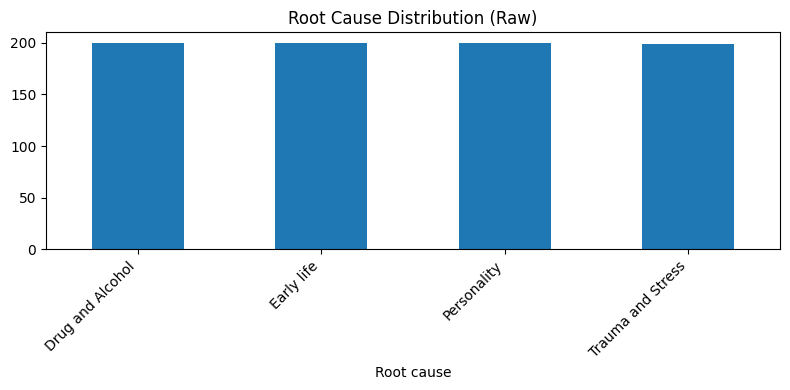

In [64]:
import matplotlib.pyplot as plt

print("Raw root-cause value counts:")
print(df[ROOT_COL].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
df[ROOT_COL].value_counts().plot(kind="bar")
plt.title("Root Cause Distribution (Raw)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [65]:
# Drop rows with missing root cause
df_root = df.dropna(subset=[ROOT_COL]).copy()

# Normalize to string and strip whitespace
df_root[ROOT_COL] = df_root[ROOT_COL].astype(str).str.strip()

print("After dropping NA:")
print(df_root[ROOT_COL].value_counts(dropna=False))
print("Rows remaining:", len(df_root))


After dropping NA:
Root cause
Drug and Alcohol     200
Early life           200
Personality          200
Trauma and Stress    199
Name: count, dtype: int64
Rows remaining: 799


In [66]:
# Example mapping – adjust keys to match your actual raw labels, if different
root_map = {
    "Personality": "Personality",
    "personality": "Personality",

    "Trauma and stress": "Trauma/Stress",
    "Trauma & Stress": "Trauma/Stress",
    "Stress": "Trauma/Stress",
    "Trauma": "Trauma/Stress",

    "Early life": "Early Life",
    "Early life experiences": "Early Life",

    "Drug and alcohol": "Substance Use",
    "Drugs and alcohol": "Substance Use",
    "Substance use": "Substance Use",
    "Alcohol": "Substance Use",
    "Addiction": "Substance Use",
}

def map_root_cause(x):
    x = str(x).strip()
    return root_map.get(x, x)  # if not in dict, keep original

df_root["Root_cause_clean"] = df_root[ROOT_COL].apply(map_root_cause)

print("Cleaned root-cause value counts:")
print(df_root["Root_cause_clean"].value_counts(dropna=False))


Cleaned root-cause value counts:
Root_cause_clean
Drug and Alcohol     200
Early Life           200
Personality          200
Trauma and Stress    199
Name: count, dtype: int64


In [67]:
min_samples = 30  # you can tune this

value_counts = df_root["Root_cause_clean"].value_counts()
valid_labels = value_counts[value_counts >= min_samples].index.tolist()

print("Labels kept as individual classes:", valid_labels)

def merge_rare(label):
    if label in valid_labels:
        return label
    return "Others"

df_root["Root_cause_final"] = df_root["Root_cause_clean"].apply(merge_rare)

print("Final root-cause distribution after merging rares:")
print(df_root["Root_cause_final"].value_counts(dropna=False))


Labels kept as individual classes: ['Drug and Alcohol', 'Early Life', 'Personality', 'Trauma and Stress']
Final root-cause distribution after merging rares:
Root_cause_final
Drug and Alcohol     200
Early Life           200
Personality          200
Trauma and Stress    199
Name: count, dtype: int64


In [68]:
min_samples = 30  # you can tune this

value_counts = df_root["Root_cause_clean"].value_counts()
valid_labels = value_counts[value_counts >= min_samples].index.tolist()

print("Labels kept as individual classes:", valid_labels)

def merge_rare(label):
    if label in valid_labels:
        return label
    return "Others"

df_root["Root_cause_final"] = df_root["Root_cause_clean"].apply(merge_rare)

print("Final root-cause distribution after merging rares:")
print(df_root["Root_cause_final"].value_counts(dropna=False))


Labels kept as individual classes: ['Drug and Alcohol', 'Early Life', 'Personality', 'Trauma and Stress']
Final root-cause distribution after merging rares:
Root_cause_final
Drug and Alcohol     200
Early Life           200
Personality          200
Trauma and Stress    199
Name: count, dtype: int64


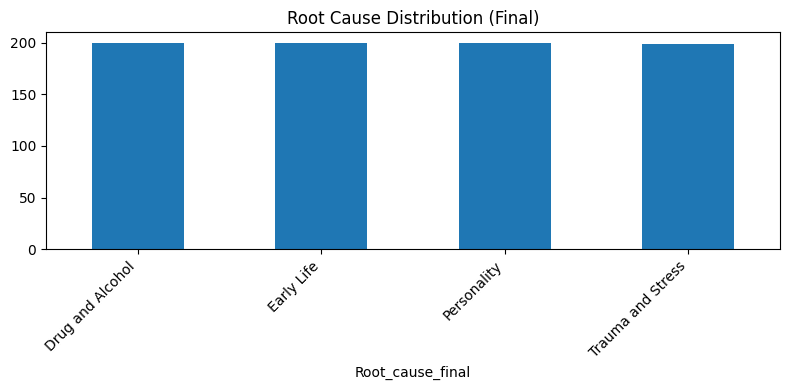

In [69]:
plt.figure(figsize=(8, 4))
df_root["Root_cause_final"].value_counts().plot(kind="bar")
plt.title("Root Cause Distribution (Final)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

X_root = df_root["text"].astype(str).tolist()
y_root = df_root["Root_cause_final"].astype(str).tolist()

X_train_root_text, X_test_root_text, y_train_root, y_test_root = train_test_split(
    X_root, y_root,
    test_size=0.2,
    random_state=42,
    stratify=y_root
)

tfidf_root = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_root_tfidf = tfidf_root.fit_transform(X_train_root_text)
X_test_root_tfidf = tfidf_root.transform(X_test_root_text)

logreg_root = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
    multi_class="multinomial"
)
logreg_root.fit(X_train_root_tfidf, y_train_root)

y_pred_root = logreg_root.predict(X_test_root_tfidf)

print("=== TF-IDF + Logistic Regression (Root Cause) ===")
print("Accuracy:", accuracy_score(y_test_root, y_pred_root))
print("Macro F1:", f1_score(y_test_root, y_pred_root, average="macro"))
print("\nClassification report:\n", classification_report(y_test_root, y_pred_root))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== TF-IDF + Logistic Regression (Root Cause) ===
Accuracy: 0.65625
Macro F1: 0.6561235380387227

Classification report:
                    precision    recall  f1-score   support

 Drug and Alcohol       0.80      0.70      0.75        40
       Early Life       0.64      0.72      0.68        40
      Personality       0.59      0.68      0.63        40
Trauma and Stress       0.62      0.53      0.57        40

         accuracy                           0.66       160
        macro avg       0.66      0.66      0.66       160
     weighted avg       0.66      0.66      0.66       160



In [71]:
from sklearn.preprocessing import LabelEncoder

# Re-define a global label encoder for root-cause so train_one_model uses the right classes
le = LabelEncoder()
df_root["root_label_id"] = le.fit_transform(df_root["Root_cause_final"])

print("Root Cause Classes:", list(le.classes_))

texts_root = df_root["text"].astype(str).tolist()
labels_root = df_root["root_label_id"].tolist()

X_train_root, X_test_root, y_train_root_ids, y_test_root_ids = train_test_split(
    texts_root,
    labels_root,
    test_size=0.2,
    random_state=42,
    stratify=labels_root
)

num_labels_root = len(le.classes_)
print("num_labels_root:", num_labels_root)


Root Cause Classes: ['Drug and Alcohol', 'Early Life', 'Personality', 'Trauma and Stress']
num_labels_root: 4


In [72]:
results_root_transformers = {}

model_names_root = [
    "distilbert-base-uncased",
    "microsoft/deberta-base",
    "google/electra-base-discriminator",
    "roberta-base"
]

for mname in model_names_root:
    try:
        metrics, model = train_one_model(
            model_name=mname,
            train_texts=X_train_root,
            train_labels=y_train_root_ids,
            test_texts=X_test_root,
            test_labels=y_test_root_ids,
            num_labels=num_labels_root,
            num_epochs=5,   # can later increase to 5–6
            batch_size=8,
            max_length=256,
            lr=2e-5
        )
        results_root_transformers[mname] = metrics
    except Exception as e:
        print(f"\n[ERROR] Model {mname} failed with error:\n{e}\n")
        continue

print("\n================ SUMMARY (Root Cause, Transformers) ================")
for mname, met in results_root_transformers.items():
    print(f"{mname}: accuracy={met['accuracy']:.4f}, macro_f1={met['macro_f1']:.4f}")




========== Training distilbert-base-uncased ==========


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 - avg training loss: 1.3391
Epoch 1 - eval loss: 1.1033 | accuracy: 0.6500 | macro F1: 0.6492


Epoch 2/5:   0%|          | 0/80 [00:00<?, ?it/s]

...

Epoch 3 - avg training loss: 0.4433
Epoch 3 - eval loss: 0.5360 | accuracy: 0.8125 | macro F1: 0.8121


Epoch 4/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 4 - avg training loss: 0.2442
Epoch 4 - eval loss: 0.6914 | accuracy: 0.8063 | macro F1: 0.8019


Epoch 5/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 5 - avg training loss: 0.1477
Epoch 5 - eval loss: 0.6698 | accuracy: 0.8125 | macro F1: 0.8107

Final evaluation on test set:
                   precision    recall  f1-score   support

 Drug and Alcohol       0.83      0.95      0.88        40
       Early Life       0.79      0.82      0.80        40
      Personality       0.76      0.78      0.77        40
Trauma and Stress       0.90      0.70      0.79        40

         accuracy                           0.81       160
        macro avg       0.82      0.81      0.81       160
     weighted avg       0.82      0.81      0.81       160


================ SUMMARY (Root Cause, Transformers) ================
distilbert-base-uncased: accuracy=0.8125, macro_f1=0.8090
microsoft/deberta-base: accuracy=0.7500, macro_f1=0.7454
google/electra-base-discriminator: accuracy=0.8187, macro_f1=0.8154
roberta-base: accuracy=0.8125, macro_f1=0.8107


In [73]:
######  Perceived Benefits #######

In [74]:
print("Columns in df:", df.columns.tolist())


Columns in df: ['score', 'selftext', 'subreddit', 'title', 'Root cause', 'Gender', 'Sentiment', 'Perceived severity', 'Perceived benefits', 'Perceived barriers', 'Cue to Action', 'Self-efficacy', 'text', 'text_len', 'label_id']


In [75]:
candidate_benefit_cols = [
    c for c in df.columns
    if "benefit" in c.lower() or "benefits" in c.lower()
]

print("Candidate benefit columns:", candidate_benefit_cols)

# If detection works:
BEN_COL = candidate_benefit_cols[0]

print("Using benefit column:", BEN_COL)


Candidate benefit columns: ['Perceived benefits']
Using benefit column: Perceived benefits


In [76]:
print("Raw Perceived Benefits value counts:")
print(df[BEN_COL].value_counts(dropna=False))


Raw Perceived Benefits value counts:
Perceived benefits
Not Mentioned                   455
Finding support                 155
Getting access to treatment     124
Improving quality of life        18
Feeling heard and understood     17
Making progress                  16
Feeling relieved                 11
Do not want to bother others      3
Name: count, dtype: int64


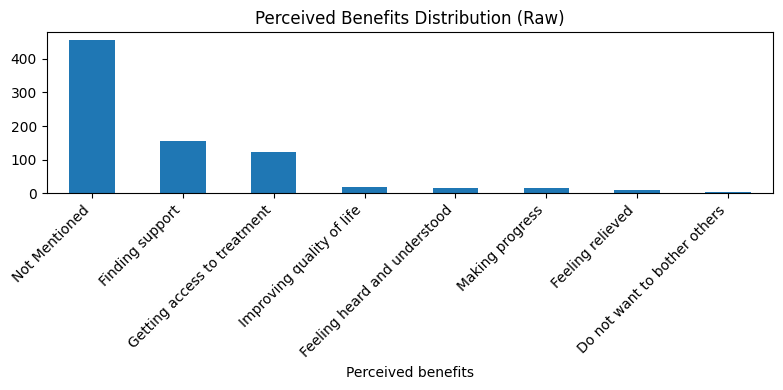

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df[BEN_COL].value_counts().plot(kind="bar")
plt.title("Perceived Benefits Distribution (Raw)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [78]:
df_benefit = df.dropna(subset=[BEN_COL]).copy()

df_benefit[BEN_COL] = df_benefit[BEN_COL].astype(str).str.strip()

print("Value counts after dropping NA:")
print(df_benefit[BEN_COL].value_counts())


Value counts after dropping NA:
Perceived benefits
Not Mentioned                   455
Finding support                 155
Getting access to treatment     124
Improving quality of life        18
Feeling heard and understood     17
Making progress                  16
Feeling relieved                 11
Do not want to bother others      3
Name: count, dtype: int64


In [79]:
benefit_map = {
    "support": "Support",
    "finding support": "Support",

    "feeling heard": "Validation",
    "validation": "Validation",
    "feel understood": "Validation",

    "treatment": "Treatment",
    "access to treatment": "Treatment",
    "therapy": "Treatment",

    "not mentioned": "Not Mentioned",
    "none": "Not Mentioned",
}

def map_benefit(x):
    x = str(x).strip().lower()
    return benefit_map.get(x, x.title())  # default: capitalize

df_benefit["benefit_clean"] = df_benefit[BEN_COL].apply(map_benefit)

print(df_benefit["benefit_clean"].value_counts())


benefit_clean
Not Mentioned                   455
Support                         155
Getting Access To Treatment     124
Improving Quality Of Life        18
Feeling Heard And Understood     17
Making Progress                  16
Feeling Relieved                 11
Do Not Want To Bother Others      3
Name: count, dtype: int64


In [80]:
min_samples = 30   # adjust if needed

value_counts = df_benefit["benefit_clean"].value_counts()
valid_labels = value_counts[value_counts >= min_samples].index.tolist()

print("Labels kept:", valid_labels)

def merge_rare_benefits(label):
    if label in valid_labels:
        return label
    return "Others"

df_benefit["benefit_final"] = df_benefit["benefit_clean"].apply(merge_rare_benefits)

print("Final benefit distribution:")
print(df_benefit["benefit_final"].value_counts())


Labels kept: ['Not Mentioned', 'Support', 'Getting Access To Treatment']
Final benefit distribution:
benefit_final
Not Mentioned                  455
Support                        155
Getting Access To Treatment    124
Others                          65
Name: count, dtype: int64


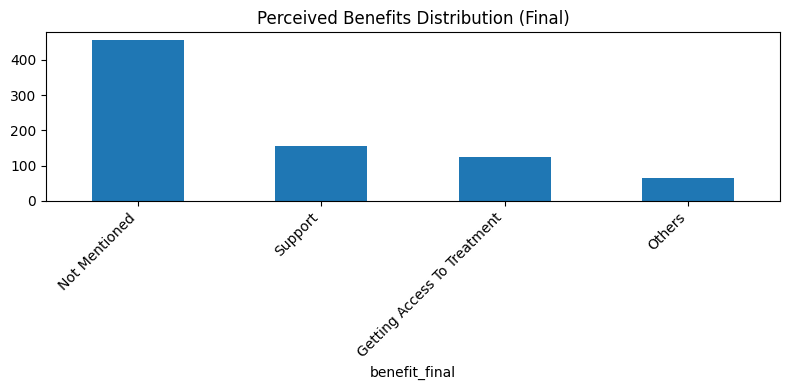

In [81]:
plt.figure(figsize=(8, 4))
df_benefit["benefit_final"].value_counts().plot(kind="bar")
plt.title("Perceived Benefits Distribution (Final)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

X_ben = df_benefit["text"].astype(str).tolist()
y_ben = df_benefit["benefit_final"].astype(str).tolist()

X_train_ben_text, X_test_ben_text, y_train_ben, y_test_ben = train_test_split(
    X_ben, y_ben, 
    test_size=0.2, 
    random_state=42,
    stratify=y_ben
)

tfidf_ben = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=3)

X_train_ben_tfidf = tfidf_ben.fit_transform(X_train_ben_text)
X_test_ben_tfidf = tfidf_ben.transform(X_test_ben_text)

logreg_ben = LogisticRegression(max_iter=300, n_jobs=-1, multi_class="multinomial")
logreg_ben.fit(X_train_ben_tfidf, y_train_ben)

y_pred_ben = logreg_ben.predict(X_test_ben_tfidf)

print("===== TF-IDF + Logistic Regression (Perceived Benefits) =====")
print("Accuracy:", accuracy_score(y_test_ben, y_pred_ben))
print("Macro F1:", f1_score(y_test_ben, y_pred_ben, average="macro"))
print(classification_report(y_test_ben, y_pred_ben))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


===== TF-IDF + Logistic Regression (Perceived Benefits) =====
Accuracy: 0.6125
Macro F1: 0.29194373199075396
                             precision    recall  f1-score   support

Getting Access To Treatment       0.50      0.08      0.14        25
              Not Mentioned       0.60      1.00      0.75        91
                     Others       0.00      0.00      0.00        13
                    Support       1.00      0.16      0.28        31

                   accuracy                           0.61       160
                  macro avg       0.53      0.31      0.29       160
               weighted avg       0.61      0.61      0.50       160



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_benefit["benefit_label_id"] = le.fit_transform(df_benefit["benefit_final"])

texts_ben = df_benefit["text"].astype(str).tolist()
labels_ben = df_benefit["benefit_label_id"].tolist()

X_train_ben, X_test_ben, y_train_ben_ids, y_test_ben_ids = train_test_split(
    texts_ben, labels_ben,
    test_size=0.2,
    random_state=42,
    stratify=labels_ben
)

num_labels_ben = len(le.classes_)
print("Perceived Benefit Classes:", le.classes_)


Perceived Benefit Classes: ['Getting Access To Treatment' 'Not Mentioned' 'Others' 'Support']


In [84]:
results_benefit_transformers = {}

model_names_benefit = [
    "distilbert-base-uncased",
    "microsoft/deberta-base",
    "google/electra-base-discriminator",
    "roberta-base"
]

for model_name in model_names_benefit:
    try:
        print("\n==============================")
        print("Training:", model_name)
        metrics, model = train_one_model(
            model_name=model_name,
            train_texts=X_train_ben,
            train_labels=y_train_ben_ids,
            test_texts=X_test_ben,
            test_labels=y_test_ben_ids,
            num_labels=num_labels_ben,
            num_epochs=5,
            batch_size=8,
            max_length=256,
            lr=2e-5
        )
        results_benefit_transformers[model_name] = metrics
    except Exception as e:
        print(f"\n[ERROR] {model_name} failed:\n{e}\n")

print("\n===== SUMMARY: Transformer Performance (Perceived Benefits) =====")
for m, r in results_benefit_transformers.items():
    print(f"{m}: accuracy={r['accuracy']:.4f}, macro_f1={r['macro_f1']:.4f}")



Training: distilbert-base-uncased


========== Training distilbert-base-uncased ==========


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 - avg training loss: 1.2032
Epoch 1 - eval loss: 1.0733 | accuracy: 0.5687 | macro F1: 0.1813


Epoch 2/5:   0%|          | 0/80 [00:00<?, ?it/s]

...

Epoch 3 - avg training loss: 0.7237
Epoch 3 - eval loss: 0.9315 | accuracy: 0.6188 | macro F1: 0.4405


Epoch 4/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 4 - avg training loss: 0.5349
Epoch 4 - eval loss: 1.0416 | accuracy: 0.6375 | macro F1: 0.4653


Epoch 5/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 5 - avg training loss: 0.4128
Epoch 5 - eval loss: 1.0223 | accuracy: 0.7000 | macro F1: 0.5068

Final evaluation on test set:
                             precision    recall  f1-score   support

Getting Access To Treatment       0.50      0.84      0.63        25
              Not Mentioned       0.83      0.82      0.83        91
                     Others       0.00      0.00      0.00        13
                    Support       0.64      0.52      0.57        31

                   accuracy                           0.70       160
                  macro avg       0.49      0.55      0.51       160
               weighted avg       0.68      0.70      0.68       160


===== SUMMARY: Transformer Performance (Perceived Benefits) =====
distilbert-base-uncased: accuracy=0.6250, macro_f1=0.4151
microsoft/deberta-base: accuracy=0.6250, macro_f1=0.4935
google/electra-base-discriminator: accuracy=0.6125, macro_f1=0.4072
roberta-base: accuracy=0.7000, macro_f1=0.5068


In [85]:
###### Data augmenation ######

In [94]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.6 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install wordnet

In [95]:
!pip install nlpaug


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [110]:
import nlpaug.augmenter.word as naw
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

# 🔑 Critical monkey-patch for nlpaug
import nlpaug.model.word_dict.wordnet as naw_wordnet
naw_wordnet.wordnet = wordnet



[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jovyan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [113]:
# Simple word-level augmenters
syn_aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)     # replace ~20% words with synonyms
swap_aug = naw.RandomWordAug(action='swap', aug_p=0.1)     # randomly swap some words

def augment_text_once(text: str) -> str:
    """Apply a pipeline of simple augmentations to one text."""
    t = syn_aug.augment(text)
    t = swap_aug.augment(t)
    return t

def augment_minority_in_train(X_train, y_train, min_count=80, n_aug=1):
    """
    Oversample minority classes in the training set using text augmentation.

    X_train: list of texts
    y_train: list of string labels
    min_count: classes with < min_count examples will be augmented
    n_aug: how many augmented copies per original sample (for minority classes)
    """
    import pandas as pd
    from collections import Counter

    df_train = pd.DataFrame({"text": X_train, "label": y_train})

    # Count label frequencies in train set
    label_counts = Counter(y_train)
    print("Train label counts before augmentation:", label_counts)

    # Identify minority labels
    minority_labels = [lbl for lbl, cnt in label_counts.items() if cnt < min_count]
    print("Minority labels (to augment):", minority_labels)

    aug_texts = []
    aug_labels = []

    for lbl in minority_labels:
        subset = df_train[df_train["label"] == lbl]
        for _, row in subset.iterrows():
            original_text = row["text"]
            for _ in range(n_aug):
                try:
                    new_text = augment_text_once(original_text)
                    aug_texts.append(new_text)
                    aug_labels.append(lbl)
                except Exception as e:
                    # In case augmentation fails for some weird text
                    print("Augmentation error on text, skipping:", e)
                    continue

    print(f"Generated {len(aug_texts)} augmented samples.")

    # Combine original + augmented
    X_train_aug = list(X_train) + aug_texts
    y_train_aug = list(y_train) + aug_labels

    # Shuffle (optional but recommended)
    from sklearn.utils import shuffle
    X_train_aug, y_train_aug = shuffle(X_train_aug, y_train_aug, random_state=42)

    # Report new counts
    from collections import Counter
    new_counts = Counter(y_train_aug)
    print("Train label counts AFTER augmentation:", new_counts)

    return X_train_aug, y_train_aug


In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score

def run_augmented_experiment(
    texts,
    labels,
    model_name="roberta-base",
    test_size=0.2,
    min_count=80,
    n_aug=1,
    num_epochs=5,
    batch_size=8,
    max_length=256,
    lr=2e-5
):
    """
    Full pipeline:
      - Train/test split
      - Data augmentation on TRAIN only (minority labels)
      - Label encoding
      - Training via train_one_model
      - Returns metrics dict
    """
    # 1. Train/test split (on original data)
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=test_size,
        random_state=42,
        stratify=labels
    )

    # 2. Augment only the training set
    X_train_aug, y_train_aug = augment_minority_in_train(
        X_train, y_train, min_count=min_count, n_aug=n_aug
    )

    # 3. Label encoding (global so train_one_model's report uses correct classes)
    global le
    le = LabelEncoder()
    y_train_ids = le.fit_transform(y_train_aug)
    y_test_ids = le.transform(y_test)

    num_labels = len(le.classes_)
    print("Classes:", le.classes_)
    print("num_labels:", num_labels)

    # 4. Train model using your existing PyTorch loop
    metrics, model = train_one_model(
        model_name=model_name,
        train_texts=X_train_aug,
        train_labels=y_train_ids,
        test_texts=X_test,
        test_labels=y_test_ids,
        num_labels=num_labels,
        num_epochs=num_epochs,
        batch_size=batch_size,
        max_length=max_length,
        lr=lr
    )

    print("\n[FINAL METRICS WITH AUGMENTATION]", model_name, metrics)
    return metrics, model


In [115]:
##### Self efficacy with augmentation ########

In [116]:
# Prepare texts + labels for self-efficacy
valid_self_eff = [
    "Troubled Mindset",
    "Overcome Mindset",
    "Empowered Mindset",
    "Denial Mindset",
]

df_se = df[df["Self-efficacy"].isin(valid_self_eff)].copy()
df_se["text_len"] = df_se["text"].astype(str).str.len()
df_se = df_se[df_se["text_len"] >= 50].copy()  # same filter you used before

texts_se = df_se["text"].astype(str).tolist()
labels_se = df_se["Self-efficacy"].astype(str).tolist()

# Run RoBERTa with data augmentation
metrics_se_aug, model_se_aug = run_augmented_experiment(
    texts=texts_se,
    labels=labels_se,
    model_name="roberta-base",
    test_size=0.2,
    min_count=80,   # labels with <80 examples in train will be augmented
    n_aug=2,        # 2 augmented versions per original minority sample
    num_epochs=5,   # you can try 5 later
    batch_size=8,
    max_length=256,
    lr=2e-5
)


Train label counts before augmentation: Counter({'Troubled Mindset': 393, 'Overcome Mindset': 120, 'Empowered Mindset': 104, 'Denial Mindset': 22})
Minority labels (to augment): ['Denial Mindset']
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on t

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 - avg training loss: 1.1626
Epoch 1 - eval loss: 0.9642 | accuracy: 0.6188 | macro F1: 0.1911


Epoch 2/5:   0%|          | 0/80 [00:00<?, ?it/s]

...

Epoch 4/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 4 - avg training loss: 0.6259
Epoch 4 - eval loss: 0.8857 | accuracy: 0.7188 | macro F1: 0.4937


Epoch 5/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 5 - avg training loss: 0.5149
Epoch 5 - eval loss: 0.8963 | accuracy: 0.7063 | macro F1: 0.4615

Final evaluation on test set:
                   precision    recall  f1-score   support

   Denial Mindset       0.00      0.00      0.00         5
Empowered Mindset       0.83      0.38      0.53        26
 Overcome Mindset       0.44      0.57      0.49        30
 Troubled Mindset       0.79      0.87      0.83        99

         accuracy                           0.71       160
        macro avg       0.51      0.45      0.46       160
     weighted avg       0.71      0.71      0.69       160


[FINAL METRICS WITH AUGMENTATION] roberta-base {'accuracy': 0.70625, 'macro_f1': 0.46149812239629173, 'eval_loss': 0.8962579719722271}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [117]:
#########   Perceived Benefits with Augmentation ########

In [ ]:
# Assuming df_benefit already built as in your pipeline:
# df_benefit["text"], df_benefit["benefit_final"] exist

texts_ben = df_benefit["text"].astype(str).tolist()
labels_ben = df_benefit["benefit_final"].astype(str).tolist()

metrics_ben_aug, model_ben_aug = run_augmented_experiment(
    texts=texts_ben,
    labels=labels_ben,
    model_name="roberta-base",
    test_size=0.2,
    min_count=60,   # tune this based on label distribution
    n_aug=1,        # start with 1, increase if still imbalanced
    num_epochs=5,
    batch_size=8,
    max_length=256,
    lr=2e-5
)


Train label counts before augmentation: Counter({'Not Mentioned': 364, 'Support': 124, 'Getting Access To Treatment': 99, 'Others': 52})
Minority labels (to augment): ['Others']
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name 'nltk' is not defined
Augmentation error on text, skipping: name

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 - avg training loss: 1.2361
Epoch 1 - eval loss: 1.0863 | accuracy: 0.5687 | macro F1: 0.1813


Epoch 2/5:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 2 - avg training loss: 0.9784
Epoch 2 - eval loss: 0.9333 | accuracy: 0.6438 | macro F1: 0.3391


Epoch 3/5:   0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
results_augmented = {}
results_augmented["self_efficacy_roberta"] = metrics_se_aug
results_augmented["benefits_roberta"] = metrics_ben_aug
